PHẦN 1: TÌM HIỂU DỮ LIỆU VÀ LÀM SẠCH LÝ DỮ LIỆU (2 ĐIỂM _ CLO 1)

In [4]:
# 1.	Đọc File với các file trong thư mục dữ liệu. . 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Đọc file.Hiển thị toàn bộ dữ liệu của file dữ liệu đã đọc
df = pd.read_csv('data-quizth03.csv', delimiter=',', header=0)
df

,CartCode,Total,Discount,CustomerSalary,CustomerAge,ListOfProduct
0,C0,100,0.09,1472,29,shrimp>almonds>avocado>vegetables mix>green gr...
1,C1,75,0.17,2113,24,burgers>meatballs>eggs
2,C2,162,0.06,1015,39,chutney
3,C3,94,0.03,2123,56,turkey>avocado
4,C4,114,0.25,1631,33,mineral water>milk>energy bar>whole wheat rice...
...,...,...,...,...,...,...
7496,C7496,122,0.25,1191,52,butter>light mayo>fresh bread
7497,C7497,206,0.09,1087,42,burgers>frozen vegetables>eggs>french fries>ma...
7498,C7498,199,0.12,1420,59,chicken
7499,C7499,82,0.23,1586,56,escalope>green tea


In [2]:
# Tìm hiểu và giải thích về bộ dữ liệu.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CartCode        7501 non-null   object 
 1   Total           7501 non-null   int64  
 2   Discount        7501 non-null   float64
 3   CustomerSalary  7501 non-null   int64  
 4   CustomerAge     7501 non-null   int64  
 5   ListOfProduct   7501 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 351.7+ KB


In [ ]:
#  Cho biết biến nào là định tính, biến nào là định lượng, kiểu dữ liệu và thang đo cho mỗi thuộc tính.

# Định tính: CartCode, ListOfProduct
# Định lượng: Total, Discount, CustomerSalary, CustomerAge

# Kiểu dữ liệu và thang đo cho mỗi thuộc tính
# CartCode: object
# ListOfProduct: object
# Total: float64
# Discount: float64
# CustomerSalary: float64
# CustomerAge: int64



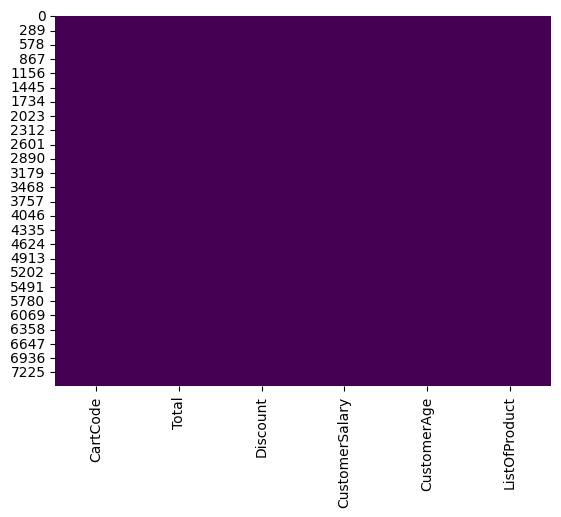

In [5]:
# 2.	Dùng biểu đồ để trực quan dữ liệu bị thiếu. 
# Biểu đồ trực quan dữ liệu bị thiếu
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [6]:
# Cho biết dữ liệu nào đang bị thiếu.
df.isnull().sum()

CartCode          0
Total             0
Discount          0
CustomerSalary    0
CustomerAge       0
ListOfProduct     0
dtype: int64

In [7]:
#  Giá trị nào bị thiếu bạn hãy điền thêm vào bằng 1 trong các cách đã được học (thay bằng giá trị yếu vị, giá trị trung bình hay 1 giá trị nào đó. Xem lại dữ liệu sau khi thay đổi
# Thay thế giá trị bị thiếu bằng giá trị trung bình của cột
df['Discount'].fillna(df['Discount'].mean(), inplace=True)
df['CustomerSalary'].fillna(df['CustomerSalary'].mean(), inplace=True)
df['CustomerAge'].fillna(df['CustomerAge'].mean(), inplace=True)
df.isnull().sum()


CartCode          0
Total             0
Discount          0
CustomerSalary    0
CustomerAge       0
ListOfProduct     0
dtype: int64

In [8]:
# 3.	Sửa dữ liệu của 1 cột nào đó theo điều kiện nào đó. Hiển thị dữ liệu của cột này. 
# Sửa dữ liệu của cột CustomerAge theo điều kiện nếu giá trị cột CustomerAge < 18 thì gán giá trị = 18
df.loc[df['CustomerAge'] < 18, 'CustomerAge'] = 18
df['CustomerAge']

0       29
1       24
2       39
3       56
4       33
        ..
7496    52
7497    42
7498    59
7499    56
7500    31
Name: CustomerAge, Length: 7501, dtype: int64

In [9]:
# 4.	Lưu trữ dữ liệu đã xử lý thành công với tên file TenFileCu_clean.csv 
df.to_csv('data-quizth03_clean.csv', index=False)
print('Lưu file thành công!')

Lưu file thành công!


PHẦN 2: XỬ LÝ DỮ LIỆU – TRỰC QUAN HOÁ DỮ LIỆU (3 ĐIỂM_CLO2)

In [10]:
# 1.	Trộn 2 bảng dữ liệu với nhau vào 1 dataframe.
df1 = pd.read_csv('data-quizth03.csv', delimiter=',', header=0)
df2 = pd.read_csv('data-quizth03_clean.csv', delimiter=',', header=0)
df = pd.concat([df1, df2], axis=0)
df

,CartCode,Total,Discount,CustomerSalary,CustomerAge,ListOfProduct
0,C0,100,0.09,1472,29,shrimp>almonds>avocado>vegetables mix>green gr...
1,C1,75,0.17,2113,24,burgers>meatballs>eggs
2,C2,162,0.06,1015,39,chutney
3,C3,94,0.03,2123,56,turkey>avocado
4,C4,114,0.25,1631,33,mineral water>milk>energy bar>whole wheat rice...
...,...,...,...,...,...,...
7496,C7496,122,0.25,1191,52,butter>light mayo>fresh bread
7497,C7497,206,0.09,1087,42,burgers>frozen vegetables>eggs>french fries>ma...
7498,C7498,199,0.12,1420,59,chicken
7499,C7499,82,0.23,1586,56,escalope>green tea


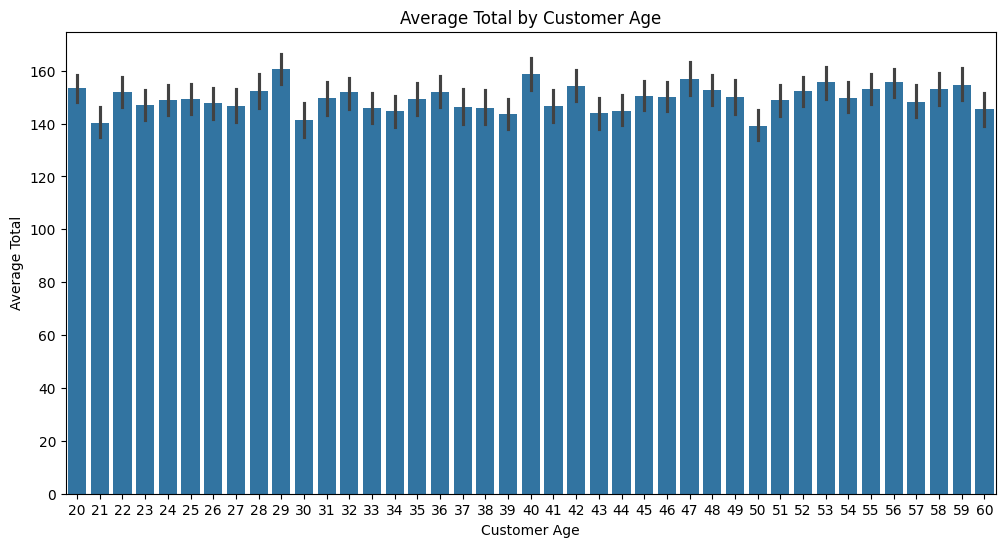

In [15]:
# 2.	Dùng biểu đồ barplot để thực hiện thống kê minh hoạ trung bình của 1 cột dữ liệu định lượng theo 1 nhóm nào đó.
plt.figure(figsize=(12, 6))

sns.barplot(x='CustomerAge', y='Total', data=df)
plt.xlabel('Customer Age')
plt.ylabel('Average Total')
plt.title('Average Total by Customer Age')
plt.show()

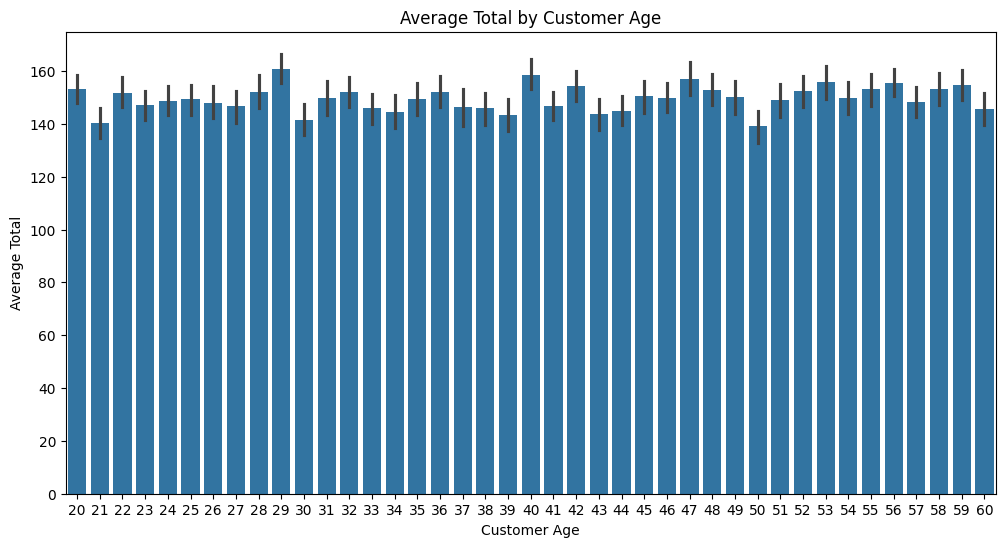

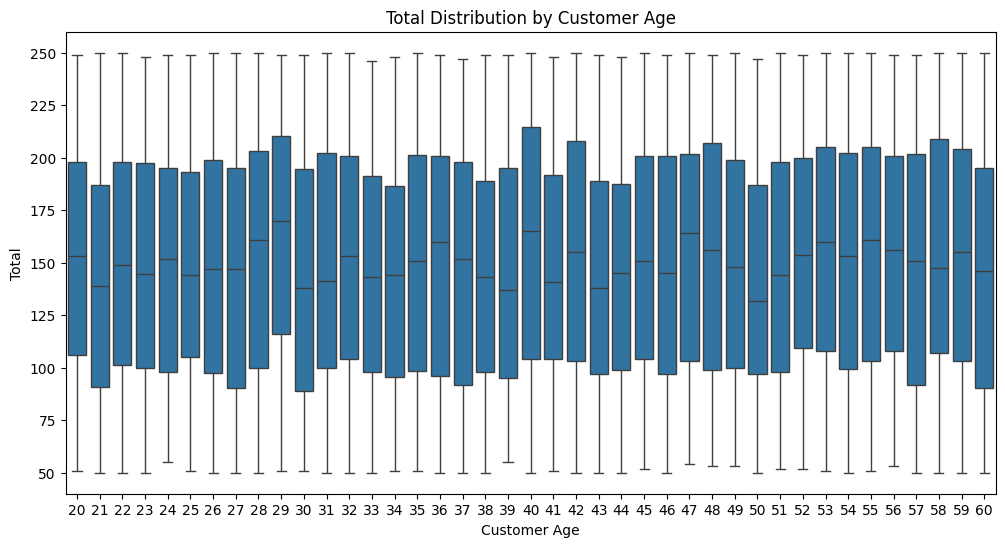

In [18]:
# 3.	Vẽ biểu đồ so sánh của 1 thuộc tính giữa các nhóm định lượng.
# Set the figure size to make the plot wider
plt.figure(figsize=(12, 6))

# Create a bar plot to compare 'Total' between different 'CustomerAge' groups
sns.barplot(x='CustomerAge', y='Total', data=df)
plt.xlabel('Customer Age')
plt.ylabel('Average Total')
plt.title('Average Total by Customer Age')
plt.show()

# Alternatively, create a box plot to compare 'Total' between different 'CustomerAge' groups
plt.figure(figsize=(12, 6))
sns.boxplot(x='CustomerAge', y='Total', data=df)
plt.xlabel('Customer Age')
plt.ylabel('Total')
plt.title('Total Distribution by Customer Age')
plt.show()


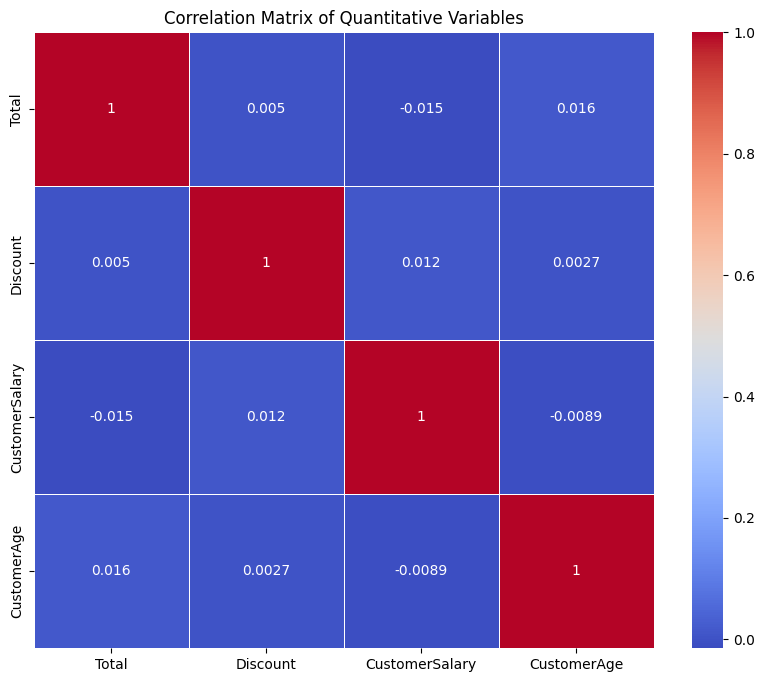

In [20]:
# 4.	Vẽ biểu đồ thể hiện sự tương quan của các biến định lượng 

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Quantitative Variables')
plt.show()

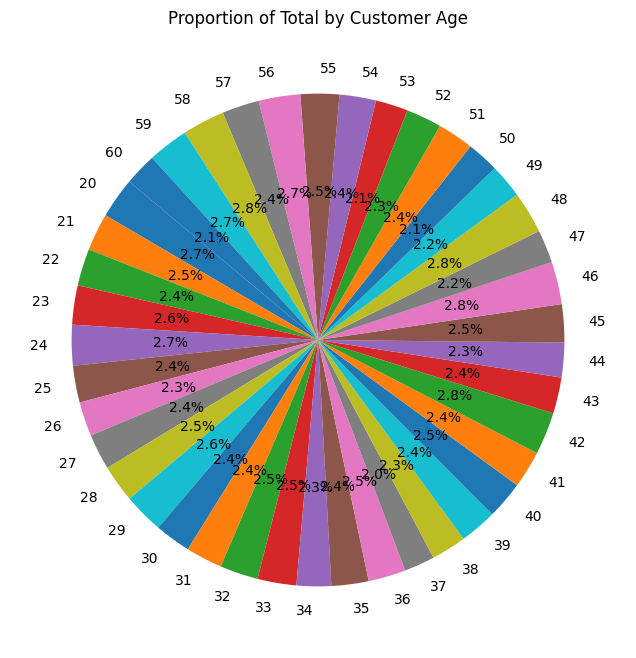

In [21]:
# 5.	Vẽ biểu đồ tròn thể hiện tỉ lệ phần trăm của 1 biến định lượng theo 1 nhóm nào đó.
# Group by 'CustomerAge' and calculate the sum of 'Total' for each group
grouped_data = df.groupby('CustomerAge')['Total'].sum()

plt.figure(figsize=(8, 8))
plt.pie(grouped_data, labels=grouped_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Total by Customer Age')
plt.show()

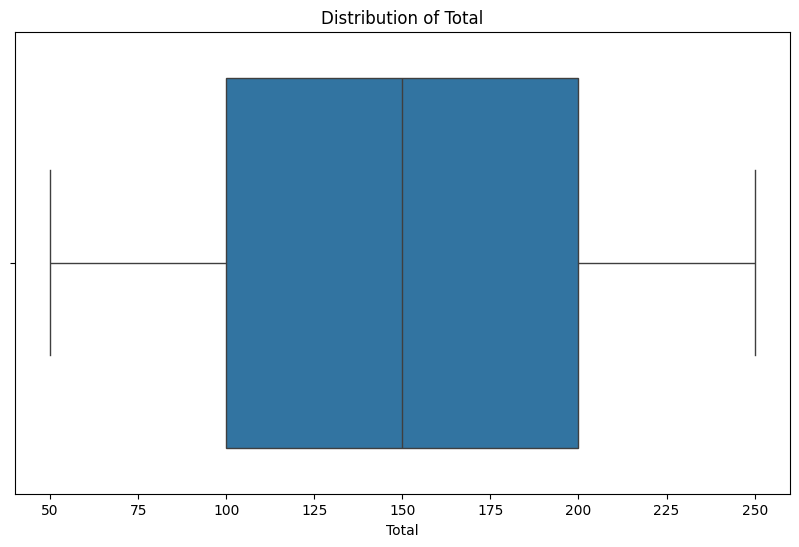

IQR: 100.0
Outliers:
Empty DataFrame
Columns: [CartCode, Total, Discount, CustomerSalary, CustomerAge, ListOfProduct]
Index: []


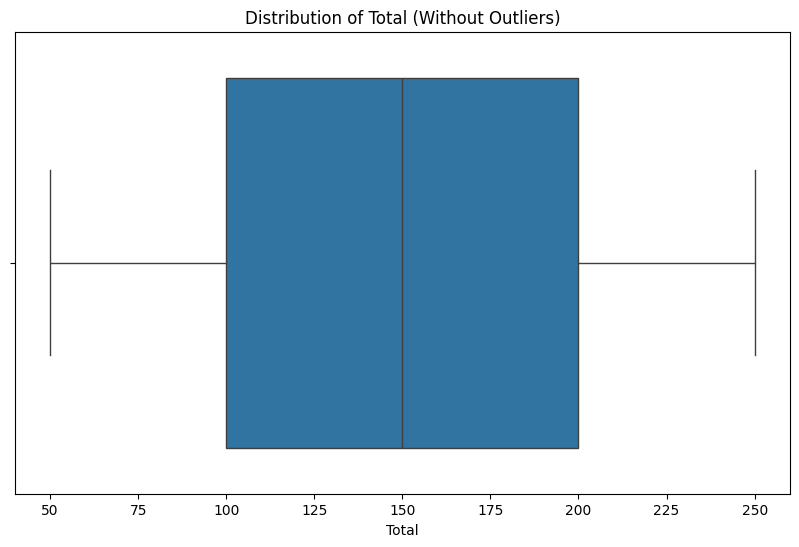

In [23]:
# 6.  Dùng biểu đồ boxlot để tìm giá trị ngoại lệ cho 1 thuộc tính nào đó. Tìm độ trải giữa (IQR) của cột dữ liệu bị ngoại lệ. Loại bỏ dữ liệu ngoại lệ. 
# Create a box plot to visualize the distribution of 'Total'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Total'])
plt.title('Distribution of Total')
plt.show()

# Calculate the IQR
Q1 = df['Total'].quantile(0.25)
Q3 = df['Total'].quantile(0.75)
IQR = Q3 - Q1

print(f'IQR: {IQR}')

# Identify outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Total'] < lower_bound) | (df['Total'] > upper_bound)]

print(f'Outliers:\n{outliers}')

# Remove outliers
df_no_outliers = df[(df['Total'] >= lower_bound) & (df['Total'] <= upper_bound)]

# Create a box plot again to visualize the distribution without outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_no_outliers['Total'])
plt.title('Distribution of Total (Without Outliers)')
plt.show()


PHẦN 3: THỐNG KÊ SUY DIỄN VÀ HỒI QUY TUYẾN TÍNH (5 ĐIỂM – CLO3)

In [24]:
# 1.	Thực hiện kiểm định trung bình của 2 biến số (định lượng) bằng phương pháp Z-Test bằng một giá trị nào đó với mức sai lầm là 10%. Cho nhận xét
from statsmodels.stats.weightstats import ztest

# Define two random samples
np.random.seed(0)
sample1 = np.random.choice(df['Total'], 100)
sample2 = np.random.choice(df['Total'], 100)

# Perform Z-test
z_stat, p_value = ztest(sample1, sample2)

alpha = 0.1

print(f'Z-statistic: {z_stat}')
print(f'p-value: {p_value}')

if p_value < alpha:
    print('Từ chối giả thuyết H0')
    print('Nhận xét: Có sự khác biệt đáng kể giữa trung bình của hai mẫu với mức sai lầm 10%.')
else:
    print('Chấp nhận giả thuyết H0')
    print('Nhận xét: Không có sự khác biệt đáng kể giữa trung bình của hai mẫu với mức sai lầm 10%.')


Z-statistic: -1.3655580619428582
p-value: 0.17207771733766775
Chấp nhận giả thuyết H0
Nhận xét: Không có sự khác biệt đáng kể giữa trung bình của hai mẫu với mức sai lầm 10%.


In [26]:
# 2.	Thực hiện kiểm định trung bình của 1 biến số (định lượng) có bằng nhau không bằng phương pháp T-Test với mức sai lầm là 5%. Cho nhận xét
from scipy.stats import ttest_ind
# Define two groups from the 'Total' column
group1 = df[df['CustomerAge'] <= 55]['Total']
group2 = df[df['CustomerAge'] > 55]['Total']

# Perform T-Test
t_stat, p_value = ttest_ind(group1, group2)

alpha = 0.05

print(f'T-statistic: {t_stat}')
print(f'P-value: {p_value}')

if p_value < alpha:
    print('Từ chối giả thuyết H0')
    print('Nhận xét: Có sự khác biệt đáng kể giữa trung bình của hai nhóm với mức sai lầm 5%.')
else:
    print('Chấp nhận giả thuyết H0')
    print('Nhận xét: Không có sự khác biệt đáng kể giữa trung bình của hai nhóm với mức sai lầm 5%.')


T-statistic: -1.665602386641695
P-value: 0.0958135173670846
Chấp nhận giả thuyết H0
Nhận xét: Không có sự khác biệt đáng kể giữa trung bình của hai nhóm với mức sai lầm 5%.


In [27]:
# 3.	Thực hiện kiểm tra 2 biến định lượng có tương quan với nhau không bằng phương pháp Chi-Square với mức sai lầm là 5%? Cho nhận xét.
# Convert quantitative variables into categorical variables by binning
from scipy.stats import chi2_contingency
df['Total_binned'] = pd.cut(df['Total'], bins=3, labels=['Low', 'Medium', 'High'])
df['CustomerSalary_binned'] = pd.cut(df['CustomerSalary'], bins=3, labels=['Low', 'Medium', 'High'])

# Create a contingency table
contingency_table = pd.crosstab(df['Total_binned'], df['CustomerSalary_binned'])

# Perform Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

alpha = 0.05

print(f'Chi-Square statistic: {chi2}')
print(f'P-value: {p}')

if p < alpha:
    print('Từ chối giả thuyết H0')
    print('Nhận xét: Có sự tương quan đáng kể giữa hai biến với mức sai lầm 5%.')
else:
    print('Chấp nhận giả thuyết H0')
    print('Nhận xét: Không có sự tương quan đáng kể giữa hai biến với mức sai lầm 5%.')

Chi-Square statistic: 5.290283556138293
P-value: 0.258787888334729
Chấp nhận giả thuyết H0
Nhận xét: Không có sự tương quan đáng kể giữa hai biến với mức sai lầm 5%.


In [28]:
# 4.	Thực hiện kiểm định ANOVA 2 chiều. Giải thích kết quả.
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Convert 'CustomerAge' and 'Discount' to categorical variables
df['CustomerAge'] = pd.cut(df['CustomerAge'], bins=3, labels=['Young', 'Middle-aged', 'Old'])
df['Discount'] = pd.cut(df['Discount'], bins=3, labels=['Low', 'Medium', 'High'])

# Fit the ANOVA model
model = ols('Total ~ C(CustomerAge) + C(Discount) + C(CustomerAge):C(Discount)', data=df).fit()

# Perform the ANOVA test
anova_results = anova_lm(model)

print(anova_results)

# Interpretation
alpha = 0.05
for index, row in anova_results.iterrows():
    if row['PR(>F)'] < alpha:
        print(f'Từ chối giả thuyết H0 cho {index}')
        print(f'Nhận xét: Có sự khác biệt đáng kể giữa các nhóm {index} với mức sai lầm 5%.')
    else:
        print(f'Chấp nhận giả thuyết H0 cho {index}')
        print(f'Nhận xét: Không có sự khác biệt đáng kể giữa các nhóm {index} với mức sai lầm 5%.')

                                 df        sum_sq       mean_sq         F  \
C(CustomerAge)                  2.0  1.996861e+04   9984.304865  2.970945   
C(Discount)                     2.0  1.757799e+04   8788.993940  2.615266   
C(CustomerAge):C(Discount)      4.0  4.765665e+04  11914.162128  3.545196   
Residual                    14993.0  5.038622e+07   3360.649863       NaN   

                              PR(>F)  
C(CustomerAge)              0.051285  
C(Discount)                 0.073182  
C(CustomerAge):C(Discount)  0.006757  
Residual                         NaN  
Chấp nhận giả thuyết H0 cho C(CustomerAge)
Nhận xét: Không có sự khác biệt đáng kể giữa các nhóm C(CustomerAge) với mức sai lầm 5%.
Chấp nhận giả thuyết H0 cho C(Discount)
Nhận xét: Không có sự khác biệt đáng kể giữa các nhóm C(Discount) với mức sai lầm 5%.
Từ chối giả thuyết H0 cho C(CustomerAge):C(Discount)
Nhận xét: Có sự khác biệt đáng kể giữa các nhóm C(CustomerAge):C(Discount) với mức sai lầm 5%.
Chấp nhận giả

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     3.244
Date:                Fri, 11 Oct 2024   Prob (F-statistic):             0.0717
Time:                        11:24:17   Log-Likelihood:                -82201.
No. Observations:               15002   AIC:                         1.644e+05
Df Residuals:                   15000   BIC:                         1.644e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            151.7851      1.306    116.

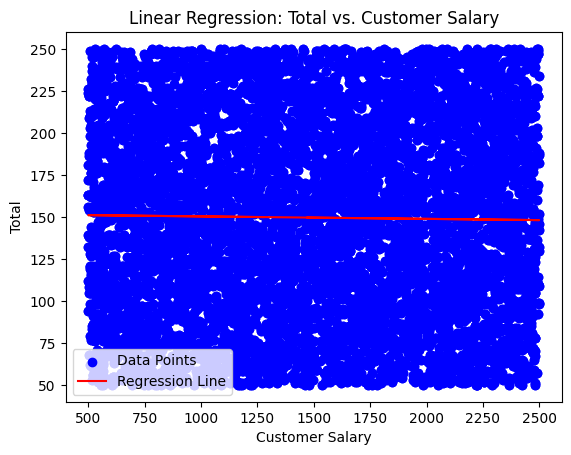

In [36]:
# 5.	Đánh giá mức độ tác động giữa các yếu tố đến 1 đối tượng (1 biến độc lập và 1 biến phụ thuộc) bằng phân tích hồi quy tuyến tính theo phương thức OLS. Giải thích kết quả
import statsmodels.api as sm

# Định nghĩa biến độc lập (predictor) và biến phụ thuộc (target)
X = df['CustomerSalary']  # Biến độc lập
y = df['Total']  # Biến phụ thuộc

# Thêm một hằng số vào biến độc lập
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(model.summary())


coefficients = model.params


# Interpretation
p_values = model.pvalues

print(f'Coefficients:\n{coefficients}')
print(f'P-values:\n{p_values}')

alpha = 0.05

for param, p_value in p_values.items():
    if p_value < alpha:
        print(f'Từ chối giả thuyết H0 cho {param}')
        print(f'Nhận xét: {param} có tác động đáng kể đến biến phụ thuộc với mức sai lầm 5%.')
    else:
        print(f'Chấp nhận giả thuyết H0 cho {param}')
        print(f'Nhận xét: {param} không có tác động đáng kể đến biến phụ thuộc với mức sai lầm 5%.')


# Viết phương trình hồi quy tuyến tính
intercept = coefficients['const']
slope = coefficients['CustomerSalary']
print(f'Phương trình hồi quy tuyến tính: Total = {intercept:.2f} + {slope:.4f} * CustomerSalary')

# Plot the data points
plt.scatter(df['CustomerSalary'], df['Total'], color='blue', label='Data Points')

# Plot the regression line
regression_line = intercept + slope * df['CustomerSalary']
plt.plot(df['CustomerSalary'], regression_line, color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Customer Salary')
plt.ylabel('Total')
plt.title('Linear Regression: Total vs. Customer Salary')
plt.legend()

# Display the plot
plt.show()